In [1]:
import tensorflow as tf
import os
import numpy as np
import keras
from keras import layers
from tensorflow import data as tf_data
import matplotlib.pyplot as plt
from tensorflow.keras.applications import EfficientNetB0

data_dir = "MushroomPics"
dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    labels="inferred",
    label_mode="categorical",
    image_size=(224, 224),
    batch_size=16,
    shuffle=True
)
length = tf.data.experimental.cardinality(dataset).numpy()

train_size = int(length * 0.7)
test_size = int(length * 0.15)

train = dataset.take(train_size)
remaining = dataset.skip(train_size)
test = remaining.take(test_size)
val = remaining.skip(test_size)

AUTOTUNE = tf.data.AUTOTUNE

train = train.prefetch(buffer_size=AUTOTUNE)
val = val.prefetch(buffer_size=AUTOTUNE)
test = test.prefetch(buffer_size=AUTOTUNE)

print(dataset.class_names)
print(dataset)

C:\Users\leevi\anaconda3\envs\keras\Lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


Found 6714 files belonging to 9 classes.
['Agaricus', 'Amanita', 'Boletus', 'Cortinarius', 'Entoloma', 'Hygrocybe', 'Lactarius', 'Russula', 'Suillus']
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 9), dtype=tf.float32, name=None))>


In [2]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
])

In [3]:
base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

base_model.trainable = False

In [4]:
model = tf.keras.Sequential([
    data_augmentation,

    layers.Rescaling(1./255),

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation='relu'),

    layers.Dropout(0.5),

    layers.Dense(len(dataset.class_names), activation="softmax")
])

In [5]:
model.compile(
    optimizer='adam',
    loss="categorical_crossentropy",
    metrics=['accuracy']
)

In [6]:
history = model.fit(
    train,
    validation_data=val,
    epochs=12
)

Epoch 1/12
294/294 ━━━━━━━━━━━━━━━━━━━━ 324s 982ms/step - accuracy: 0.2094 - loss: 2.0920 - val_accuracy: 0.2625 - val_loss: 2.0263
Epoch 2/12
294/294 ━━━━━━━━━━━━━━━━━━━━ 283s 961ms/step - accuracy: 0.2253 - loss: 2.0693 - val_accuracy: 0.2595 - val_loss: 2.0077
Epoch 3/12
294/294 ━━━━━━━━━━━━━━━━━━━━ 281s 956ms/step - accuracy: 0.2285 - loss: 2.0641 - val_accuracy: 0.2605 - val_loss: 2.0184
Epoch 4/12
294/294 ━━━━━━━━━━━━━━━━━━━━ 281s 954ms/step - accuracy: 0.2292 - loss: 2.0670 - val_accuracy: 0.2635 - val_loss: 2.0228
Epoch 5/12
294/294 ━━━━━━━━━━━━━━━━━━━━ 323s 956ms/step - accuracy: 0.2302 - loss: 2.0581 - val_accuracy: 0.2605 - val_loss: 2.0109
Epoch 6/12
294/294 ━━━━━━━━━━━━━━━━━━━━ 281s 957ms/step - accuracy: 0.2296 - loss: 2.0557 - val_accuracy: 0.2575 - val_loss: 2.0159
Epoch 7/12
294/294 ━━━━━━━━━━━━━━━━━━━━ 322s 958ms/step - accuracy: 0.2307 - loss: 2.0549 - val_accuracy: 0.2615 - val_loss: 2.0111
Epoch 8/12
294/294 ━━━━━━━━━━━━━━━━━━━━ 283s 962ms/step - accuracy: 0.2292 -

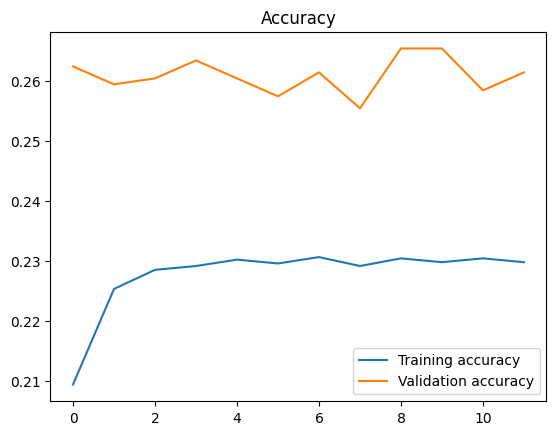

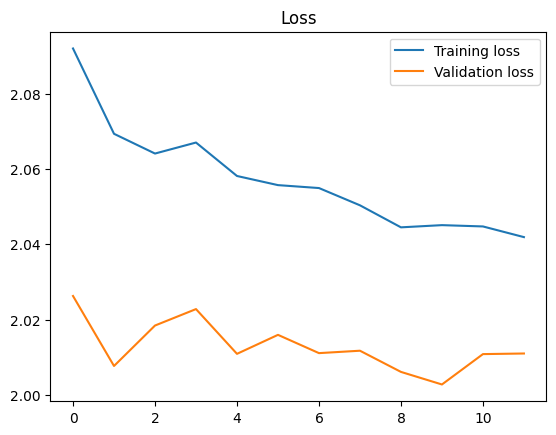

In [7]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, label='Training accuracy')
plt.plot(epochs, val_acc, label='Validation accuracy')
plt.legend()
plt.title('Accuracy')
plt.show()

plt.plot(epochs, loss, label='Training loss')
plt.plot(epochs, val_loss, label='Validation loss')
plt.legend()
plt.title('Loss')
plt.show()

In [8]:
test_loss, test_acc = model.evaluate(test)
val_loss, val_acc = model.evaluate(val)
print("Test accuracy:", test_acc)
print("Validation accuracy:", val_acc)

63/63 ━━━━━━━━━━━━━━━━━━━━ 54s 656ms/step - accuracy: 0.2143 - loss: 2.0776
63/63 ━━━━━━━━━━━━━━━━━━━━ 56s 657ms/step - accuracy: 0.2605 - loss: 2.0063
Test accuracy: 0.2142857164144516
Validation accuracy: 0.26047903299331665
